In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp

ChatGPT was able to help with the following code for exact diagonalization which we will use to initialize the circuit

In [2]:
import numpy as np
from qiskit import QuantumCircuit

# ---------------------------------------------------------
# Global single-qubit operators
# ---------------------------------------------------------
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1],
              [1, 0]], dtype=complex)
Z = np.array([[1, 0],
              [0, -1]], dtype=complex)

def kron_n(ops):
    out = np.array([[1]], dtype=complex)
    for op in ops:
        out = np.kron(out, op)
    return out

# ---------------------------------------------------------
# 1. Open-boundary Ising Hamiltonian
#    H = - Σ_{i=0}^{n-2} Z_i Z_{i+1}
#        - h_x Σ_i X_i
#        - h_z Σ_i Z_i
# ---------------------------------------------------------

def ising_hamiltonian_matrix(num_qubits, h_x, h_z):
    """
    Open boundary conditions:
        H = - Σ_{i=0}^{n-2} Z_i Z_{i+1}
            - h_x Σ_i X_i
            - h_z Σ_i Z_i

    Qiskit little-endian convention:
      - Basis ordered as |q_{n-1} ... q_0>
      - We treat index i as the Qiskit qubit index.
    """
    dim = 2**num_qubits
    H = np.zeros((dim, dim), dtype=complex)

    def one_body(pauli, target):
        # Build operators in order [q_{n-1}, ..., q_0]
        ops = []
        for q in range(num_qubits - 1, -1, -1):
            ops.append(pauli if q == target else I2)
        return kron_n(ops)

    def two_body_ZZ(i, j):
        ops = []
        for q in range(num_qubits - 1, -1, -1):
            if q == i or q == j:
                ops.append(Z)
            else:
                ops.append(I2)
        return kron_n(ops)

    # - Σ_{i=0}^{n-2} Z_i Z_{i+1}  (open boundary)
    for i in range(num_qubits - 1):
        H -= two_body_ZZ(i, i + 1)

    # - h_x Σ_i X_i  and  - h_z Σ_i Z_i
    for i in range(num_qubits):
        H += -h_x * one_body(X, i)
        H += -h_z * one_body(Z, i)

    return H

# ---------------------------------------------------------
# 2. Exact diagonalization ground state
# ---------------------------------------------------------

def ift_ground_state(num_qubits, h_x, h_z):
    H = ising_hamiltonian_matrix(num_qubits, h_x, h_z)
    evals, evecs = np.linalg.eigh(H)

    gs_index = np.argmin(evals)
    gs = evecs[:, gs_index]

    # Fix global phase so ⟨0...0|ψ⟩ is real and ≥ 0
    phase = np.angle(gs[0])
    gs *= np.exp(-1j * phase)
    gs /= np.linalg.norm(gs)

    return gs

# ---------------------------------------------------------
# 3. Circuit that prepares the ED ground state
# ---------------------------------------------------------

def ift_ground_state_circuit(num_qubits, h_x, h_z):
    """
    Returns a QuantumCircuit on `num_qubits` qubits
    that initializes the open-boundary IFT ground state.
    """
    gs = ift_ground_state(num_qubits, h_x, h_z)

    qc = QuantumCircuit(num_qubits)
    # amplitudes are in Qiskit's little-endian ordering already
    qc.initialize(gs, list(range(num_qubits)))
    return qc

In [89]:
num_qubits = 10
h_x = 1.06
h_z = 10
qc_gs = ift_ground_state_circuit(num_qubits, h_x, h_z)

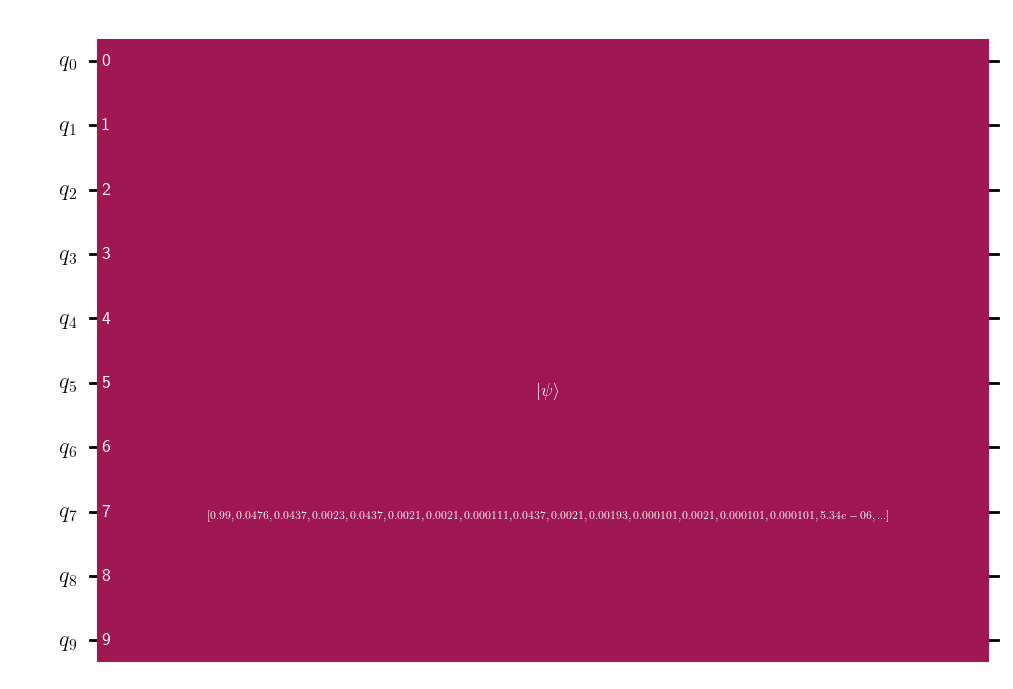

In [90]:
qc_gs.draw('mpl')

In [91]:
def build_ising_trotter(qc: QuantumCircuit, h_x: float, h_z: float, delta_t: float) -> None:
    num_qubits = qc.num_qubits
    for i in range(num_qubits - 1):
        qc.rzz(- 2 * delta_t, i, i + 1)
    for i in range(num_qubits):
        qc.rz(- 2 * h_z * delta_t, i)
        qc.rx(- 2 * h_x * delta_t, i)

In [92]:
def build_ising_circuit(t_steps: int, h_x: float, h_z: float, delta_t: float) -> QuantumCircuit:
    qc_gs = ift_ground_state_circuit(num_qubits, h_x, h_z)
    qc_gs.x(3)
    qc_gs.x(6)
    for step in range(t_steps):
        build_ising_trotter(qc_gs, h_x, h_z, delta_t)
    return qc_gs

In [93]:
num_qubits = 10
pauli_op_list = [(SparsePauliOp('I' * (i) + 'Z' + 'I' * (num_qubits - i - 1), 1.0)) for i in range(num_qubits)]

In [94]:
delta_t = 0.1

In [95]:
pubs = [(build_ising_circuit(i, h_x, h_z, delta_t), pauli_op_list) for i in range(10)]

In [96]:
estimator = StatevectorEstimator()

In [97]:
job = estimator.run(pubs)

In [82]:
s_z_exp = []

In [83]:
for i in range(10):
    s_z_exp.append(job.result()[i].data.evs)

In [84]:
from matplotlib import pyplot as plt

In [85]:
plt.rcParams['text.usetex']=True

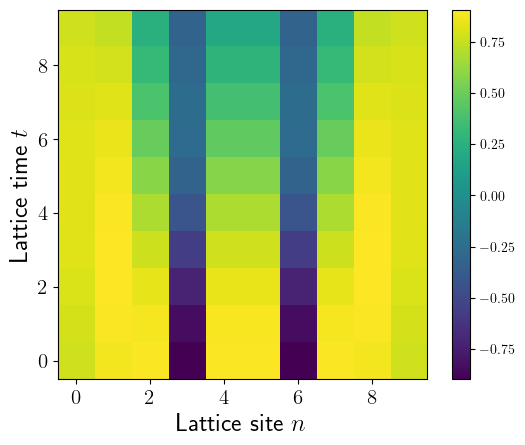

In [86]:
plt.imshow(s_z_exp, origin='lower')
plt.xlabel("Lattice site $n$", size=18)
plt.ylabel("Lattice time $t$", size=18)
plt.xticks(size=15)
plt.yticks(size=15)
plt.colorbar()
plt.savefig(f"qiskit_IFT_evolution_hx_{h_x}_hz_{h_z}".replace(".", "p") + ".png", dpi=600)